## Custom SNN LIF neuron Python implementation for electronics engineering bachelor project

In [4]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import copy
import itertools

# Custom neuron implelmentation
from LIF import LIF

# Set random seed for reproducability
np.random.seed(42)

### Simulation Setup

# rSTDP

### Simulation setup

**Parameters for grid search**

In [ ]:
# Architecture parameters
hidden_layers_range = [0]  # Zero for fully connected network
hidden_size_range = [50]   # Not used when hidden_layers=0

# Hyperparameters
beta_range = [0.8, 0.85, 0.90]
threshold_range = [5.0, 7.5, 10.0]
reset_val = 0.0
learning_rate_range = [0.02, 0.05, 0.1]
initial_weight_range = [0.25, 0.5]

# Reward parameters
dopamine_correct_range = [1.0, 2.0, 3.0, 4.0]
dopamine_wrong_range = [-0.2]
dopamine_nofire_range = [-0.05]

# Decay parameters
eligibility_decay_range = [0.90]

# Calculate total combinations
total_combinations = len(list(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    eligibility_decay_range
)))

# Pattern settings
pattern_hold_duration = 100
input_size = 15*15
output_size = 4

results_snn = []
n_runs = 3
time_steps = 2000

for config in tqdm(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    eligibility_decay_range
), total=total_combinations):
    
    (beta, thresh, lr, init_w, d_corr, d_wrng, d_nofi, elig_decay) = config

    run_accuracies = []

    for run in range(n_runs):
        # Initialize network: input → output (no hidden layers)
        input_to_output_synapses = np.random.uniform(init_w-0.1, init_w+0.1, (input_size, output_size))
        
        input_neurons = [LIF(beta=beta, threshold=thresh, learning_rate=lr, reset=reset_val) 
                        for _ in range(input_size)]
        output_neurons = [LIF(beta=beta, threshold=thresh, learning_rate=lr, reset=reset_val) 
                         for _ in range(output_size)]
        
        # Set eligibility decay
        for n in input_neurons + output_neurons:
            n.eligibility_decay = elig_decay
        
        correct_count = 0
        total_spike_events = 0

        # Training Loop
        for t in range(time_steps):
            pattern_idx = (t // pattern_hold_duration) % 10
            input_spikes, correct_output = patterns_2bit[pattern_idx]

            # Update input neurons with raw values (0,1,2,3)
            for i in range(input_size):
                input_neurons[i].update(input_spikes[i])

            # Update output neurons
            current_weights = input_to_output_synapses.copy()
            for j in range(output_size):
                synaptic_input = float(sum(current_weights[i,j] * input_spikes[i] for i in range(input_size)))
                output_neurons[j].update(synaptic_input)

            # Winner-Take-All
            fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
            winner_idx = -1
            if len(fired_indices) > 0:
                winner_idx = np.random.choice(fired_indices)
                total_spike_events += 1
                if winner_idx == correct_output:
                    correct_count += 1
                
                for j in range(output_size):
                    if j != winner_idx:
                        output_neurons[j].spk = 0
                        output_neurons[j].mem = 0

            # Reward
            if winner_idx == correct_output:
                dopamine = d_corr
            elif winner_idx == -1:
                dopamine = d_nofi
            else:
                dopamine = d_wrng

            # R-STDP
            if winner_idx != -1:
                for i in range(input_size):
                    for j in range(output_size):
                        input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                            input_to_output_synapses[i,j],
                            input_neurons[i].eligibility,
                            is_winner=(j == winner_idx),
                            dopamine=dopamine
                        )

        # Calculate accuracy
        acc = correct_count / total_spike_events if total_spike_events > 0 else 0
        run_accuracies.append(acc)

    # Store Results
    results_snn.append({
        'beta': beta,
        'threshold': thresh,
        'lr': lr,
        'init_weight': init_w,
        'd_correct': d_corr,
        'd_wrong': d_wrng,
        'd_nofire': d_nofi,
        'elig_decay': elig_decay,
        'mean_accuracy': np.mean(run_accuracies),
        'std_accuracy': np.std(run_accuracies)
    })

# Save results
df_results = pd.DataFrame(results_snn)
df_results.to_csv("CSV_results/SNN_ORB_GridSearch_Results.csv", index=False)
print(f"\nBest config: {df_results.loc[df_results['mean_accuracy'].idxmax()]}")

100%|██████████| 216/216 [1:21:57<00:00, 22.77s/it]


Best config: beta              0.800000
threshold        10.000000
lr                0.100000
init_weight       0.250000
d_correct         3.000000
d_wrong          -0.200000
d_nofire         -0.050000
elig_decay        0.900000
mean_accuracy     0.966713
std_accuracy      0.010902
Name: 66, dtype: float64


In [18]:
# Load grid search results
df = pd.read_csv("SNN_GridSearch_Results.csv")

# Top 25 configurations
top_25 = df.sort_values(by=['mean_accuracy', 'std_accuracy'], ascending=[False, True]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_accuracy', 'std_accuracy', 'beta', 'threshold', 'lr', 
              'init_weight', 'd_correct', 'd_wrong', 'elig_decay']])

# Parameter impact analysis
print("\n=== Impact of Beta on Accuracy ===")
print(df.groupby('beta')['mean_accuracy'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('threshold')['mean_accuracy'].mean())

print("\n=== Impact of Learning Rate on Accuracy ===")
print(df.groupby('lr')['mean_accuracy'].mean())

print("\n=== Impact of Initial Weight on Accuracy ===")
print(df.groupby('init_weight')['mean_accuracy'].mean())

print("\n=== Impact of Reward (d_correct) on Accuracy ===")
print(df.groupby('d_correct')['mean_accuracy'].mean())

print("\n=== Impact of Punishment (d_wrong) on Accuracy ===")
print(df.groupby('d_wrong')['mean_accuracy'].mean())

print("\n=== Impact of Eligibility Decay on Accuracy ===")
print(df.groupby('elig_decay')['mean_accuracy'].mean())

# Stable high performers
stable_high = df[(df['mean_accuracy'] > 0.6) & (df['std_accuracy'] < 0.1)]

if not stable_high.empty:
    print("\n=== Most Stable High-Performing Config ===")
    best = stable_high.sort_values(by='mean_accuracy', ascending=False).iloc[0]
    print(best)
else:
    print("\n=== No configs with >60% accuracy and <10% std ===")
    print("Best overall:")
    print(df.sort_values('mean_accuracy', ascending=False).iloc[0])

=== Top 25 SNN Configurations ===
     mean_accuracy  std_accuracy  beta  threshold    lr  init_weight  \
66        0.966713      0.010902  0.80       10.0  0.10         0.25   
93        0.966390      0.002872  0.85        5.0  0.10         0.50   
167       0.966355      0.000366  0.90        5.0  0.10         0.50   
163       0.965396      0.003942  0.90        5.0  0.10         0.25   
160       0.965206      0.002681  0.90        5.0  0.10         0.25   
156       0.964412      0.008463  0.90        5.0  0.05         0.50   
161       0.962671      0.010106  0.90        5.0  0.10         0.25   
88        0.961638      0.008741  0.85        5.0  0.10         0.25   
89        0.961345      0.004191  0.85        5.0  0.10         0.25   
111       0.960974      0.009032  0.85        7.5  0.05         0.50   
183       0.960851      0.005832  0.90        7.5  0.05         0.50   
18        0.959798      0.002025  0.80        5.0  0.10         0.25   
165       0.959366      0.0027

### **Best parameters**

**rSTDP**

In [ ]:
# Simulation parameters
time_steps = 100
pattern_hold_duration = 10

# Architecture parameter
input_size = 4*3     # Number of input neurons
output_size = 3     # Number of output neurons

# Hyperparameters
beta = 0.80
threshold = 2
reset_val = 0.0
learning_rate = 0.1
initial_weight = 0.25

# Reward parameters
dopamine_correct = 3
dopamine_wrong = -0.50
dopamine_nofire = -0.05

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []


In [44]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (225, 4)
Sucessfully created input layer with 225
Sucessfully created output layer with 4


In [45]:
for t in range(time_steps):
    pattern_idx = (t // pattern_hold_duration) % 10
    input_spikes, correct_output = patterns_2bit[pattern_idx]

    # Update input neurons with raw values (0,1,2,3)
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    current_weights = input_to_output_synapses.copy()

    # Update output neurons - use raw input values, not spikes
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_spikes[i] for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Winner-take-all
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0

    # Reward
    if winner_idx == correct_output:
        dopamine = dopamine_correct
    elif winner_idx == -1:
        dopamine = dopamine_nofire
    else:
        dopamine = dopamine_wrong

    # R-STDP
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                    dopamine=dopamine
                )

    # Record state
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)

IndexError: list index out of range

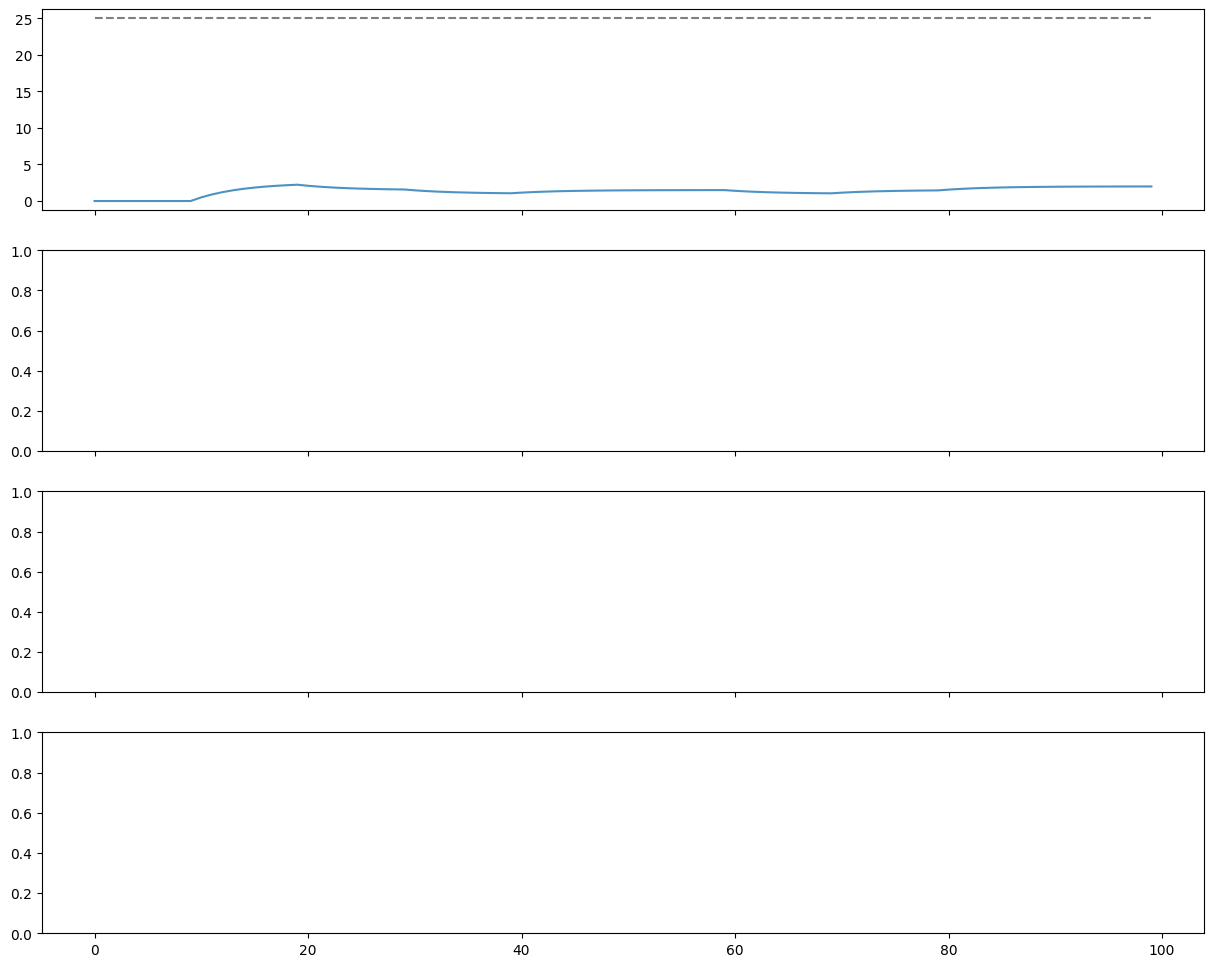

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_neuron_dynamics(mem_history, threshold_history, spike_history, target_history):
    time_steps = len(mem_history)
    num_neurons = 4  # Specifically set for your 4-pattern simulation
    
    # Create 4 subplots (one for each neuron)
    fig, axes = plt.subplots(num_neurons, 1, figsize=(15, 12), sharex=True)
    
    # Color palette for 4 distinct neurons
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    for i in range(num_neurons):
        # Extract individual neuron data
        mems = [m[i] for m in mem_history]
        threshs = [t[i] for t in threshold_history]
        spks = [s[i] for s in spike_history]
        
        # 1. Plot Membrane Potential
        axes[i].plot(mems, label=f'Neuron {i} mem-pot', color=colors[i], alpha=0.8)
        
        # 2. Plot Dynamic Threshold
        axes[i].step(range(time_steps), threshs, label='Threshold', color='black', 
                     linestyle='--', alpha=0.5, where='post')
        
        # 3. Plot Spikes (Red 'x')
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            # We plot the 'x' at the threshold level at that time
            axes[i].scatter(spike_times, [threshs[t] for t in spike_times], 
                            color='red', marker='x', s=50, label='Spikes', zorder=5)
        
        # 4. Highlight the "Target" period for this specific neuron
        # We only shade green if target_history[t] matches this neuron's index
        for t in range(time_steps):
            if target_history[t] == i:
                axes[i].axvspan(t, t+1, color='green', alpha=0.08)
        
        # Formatting
        axes[i].set_title(f"Output Neuron {i} Activity")
        axes[i].set_ylabel("Voltage")
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, which='both', linestyle=':', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")

**STDP**

In [26]:
# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []
weight_hist = []


In [27]:
# Input data
spiketrains = pd.read_csv("ORB_test_spiketrains.csv")
for spikes in spiketrains.values:
    print(spikes)

[0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 0 0 0 0 1 1 0 1 0]
[0 0 1 0 0 0 0 0 1 0 1 0]
[0 0 0 1 0 0 0 0 0 0 1 0]
[0 0 1 1 0 0 0 0 0 0 1 0]
[0 0 1 0 0 1 0 0 0 0 1 0]
[1 0 0 0 0 1 0 0 0 0 0 0]
[0 0 1 0 1 0 0 0 0 0 1 0]
[0 0 0 0 1 0 0 1 0 1 1 0]
[0 0 0 0 0 1 0 1 0 1 1 0]


In [28]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (12, 3)
Sucessfully created input layer with 12
Sucessfully created output layer with 3


In [29]:
for t in range(time_steps):
    pattern_idx = (t // pattern_hold_duration) % 10
    input_spikes = spiketrains.values[pattern_idx]

    # Update input neurons with raw values
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    current_weights = input_to_output_synapses.copy()

    # Update output neurons - use raw input values
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_spikes[i] for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Winner-take-all
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0

    # STDP (no reward signal)
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].STDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx)
                )

    # Record state
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])

In [34]:
def plot_neuron_dynamics(mem_history, threshold_history, spike_history):
    time_steps = len(mem_history)
    num_neurons = output_size
    
    # Create 4 subplots (one for each neuron)
    fig, axes = plt.subplots(num_neurons, 1, figsize=(15, 12), sharex=True)
    
    # Color palette for 4 distinct neurons
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
    
    for i in range(num_neurons):
        # Extract individual neuron data
        mems = [m[i] for m in mem_history]
        threshs = [t[i] for t in threshold_history]
        spks = [s[i] for s in spike_history]
        
        # 1. Plot Membrane Potential
        axes[i].plot(mems, label=f'Neuron {i} mem-pot', color=colors[i], alpha=0.8)
        
        # 2. Plot Dynamic Threshold
        axes[i].step(range(time_steps), threshs, label='Threshold', color='black', 
                     linestyle='--', alpha=0.5, where='post')
        
        # 3. Plot Spikes (Red 'x')
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            # We plot the 'x' at the threshold level at that time
            axes[i].scatter(spike_times, [threshs[t] for t in spike_times], 
                            color='red', marker='x', s=50, label='Spikes', zorder=5)
        
        
        # Formatting
        axes[i].set_title(f"Output Neuron {i} Activity")
        axes[i].set_ylabel("Voltage")
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, which='both', linestyle=':', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

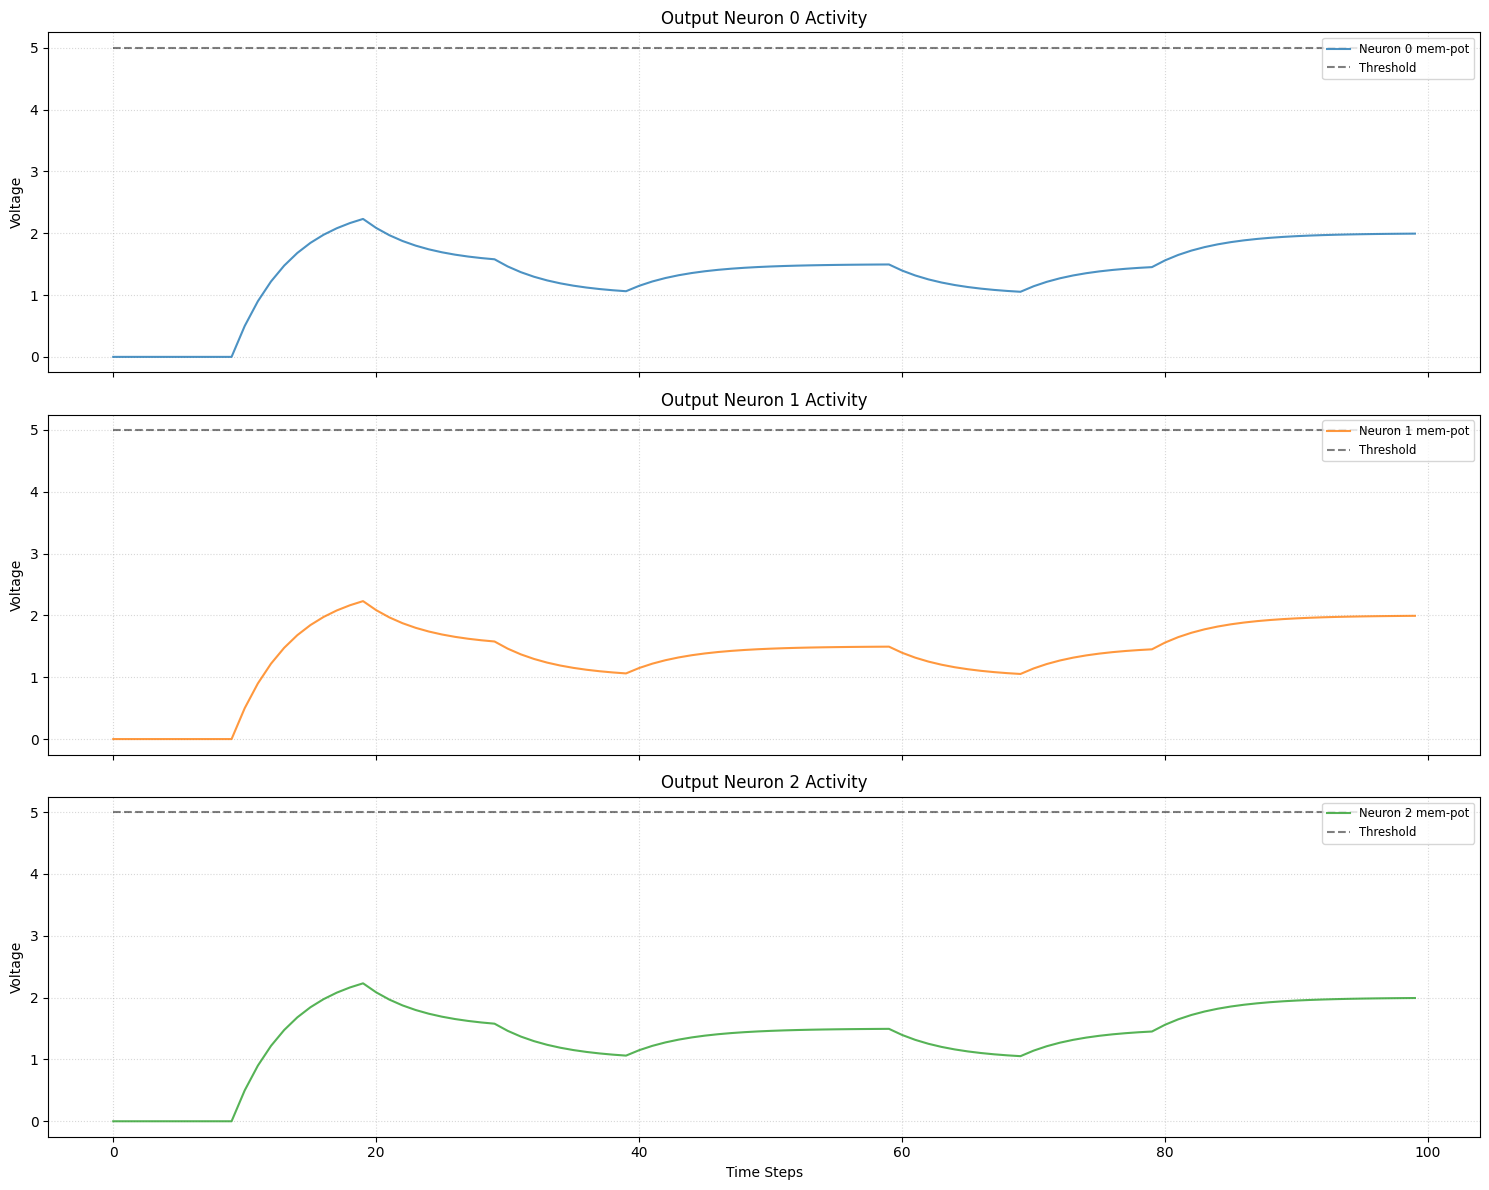


Final Accuracy: 0.0%
Correct: 0/0


In [35]:
# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")

### Simpler LIF model test

rSTDP

In [ ]:
from LIF import LIF

In [62]:
# Simulation parameters
time_steps = 1500
pattern_hold_duration = 50

# Architecture parameter
input_size = 15*15     # Number of input neurons
output_size = 4     # Number of output neurons

# Hyperparameters
beta = 0.90
threshold = 5
reset_val = 0.0
learning_rate = 0.01
initial_weight = 0.25

# Reward parameters
dopamine_correct = 7.5
dopamine_wrong = -0.50
dopamine_nofire = -0.05

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []
weight_hist = []


In [ ]:

# Instantiate synapses as a weight matrix, with all weights starting at 0.03
#input_to_output_synapses = np.full((input_size, output_size), 0.03)
input_to_output_synapses = np.random.uniform(0.05, 0.6, (input_size, output_size))
print(f"Weight stats per output neuron:")
for j in range(output_size):
    print(f"  Neuron {j}: mean={input_to_output_synapses[:, j].mean():.3f}, std={input_to_output_synapses[:, j].std():.3f}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Weight stats per output neuron:
  Neuron 0: mean=0.337, std=0.159
  Neuron 1: mean=0.332, std=0.158
  Neuron 2: mean=0.318, std=0.157
  Neuron 3: mean=0.319, std=0.155
Sucessfully created input layer with 225
Sucessfully created output layer with 4


In [64]:
# Add this at the start of your training loop (before the for loop):
debug_stats = {
    'weight_updates': [],
    'eligibility_pre': [],
    'eligibility_post': [],
    'timing_factors': [],
    'dopamine_values': [],
    'weight_ranges': [],
    'winner_distribution': [],
    'membrane_potentials': []
}

for t in range(time_steps):
    # Cycle through all 4 patterns
    pattern_idx = (t // pattern_hold_duration) % 10
    input_spikes, correct_output = patterns_2bit[pattern_idx]

    # Update input layer neurons
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    # Capture weights before update for diagnostics
    current_weights = input_to_output_synapses.copy()

    # Update output layer neurons
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_neurons[i].spk for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # === DEBUG: Capture membrane potentials ===
    if t % 50 == 0:
        debug_stats['membrane_potentials'].append([n.mem for n in output_neurons])

    # Apply winner-take-all weight updates
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0

    # === DEBUG: Track winner distribution ===
    if winner_idx != -1:  # Only track when there's actually a winner
        if t % 50 == 0:
            debug_stats['winner_distribution'].append(winner_idx)
            debug_stats['dopamine_values'].append(dopamine)
            debug_stats['membrane_potentials'].append([n.mem for n in output_neurons])

    # Calculate reward based on correct response
    if winner_idx == correct_output:
        dopamine = dopamine_correct
    elif winner_idx == -1:
        # If nothing fired lower slightly
        dopamine = dopamine_nofire
    else:
        # If wrong neuron fired, punish
        dopamine = dopamine_wrong

    # === DEBUG: Track dopamine ===
    if t % 50 == 0:
        debug_stats['dopamine_values'].append(dopamine)

    # Apply R-STDP with actual reward signal
    if winner_idx != -1:
        # === DEBUG: Sample eligibility and timing factors before learning ===
        if t % 50 == 0:
            sample_pre_elig = [input_neurons[i].eligibility for i in range(min(4, input_size))]
            sample_post_elig = output_neurons[winner_idx].eligibility
            debug_stats['eligibility_pre'].append(sample_pre_elig)
            debug_stats['eligibility_post'].append(sample_post_elig)
            
            # Calculate sample timing factor
            timing_sample = sample_pre_elig[0] * sample_post_elig if len(sample_pre_elig) > 0 else 0
            debug_stats['timing_factors'].append(timing_sample)
        
        # === DEBUG: Capture weight before update ===
        if t % 50 == 0:
            weight_before = input_to_output_synapses.copy()
        
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                    dopamine=dopamine
                )
        
        # === DEBUG: Capture weight delta ===
        if t % 50 == 0:
            weight_delta = input_to_output_synapses - weight_before
            debug_stats['weight_updates'].append({
                'mean': weight_delta.mean(),
                'max': weight_delta.max(),
                'min': weight_delta.min(),
                'std': weight_delta.std()
            })
        

    # === DEBUG: Track weight ranges ===
    if t % 50 == 0:
        debug_stats['weight_ranges'].append({
            'min': input_to_output_synapses.min(),
            'max': input_to_output_synapses.max(),
            'mean': input_to_output_synapses.mean(),
            'std': input_to_output_synapses.std()
        })

    # Record the state of the output layer at the end of the timestep
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)
    if t % 50 == 0:
        weight_hist.append(input_to_output_synapses.copy())


In [65]:
from collections import Counter

# Add this AFTER your training loop completes:

print("\n" + "="*60)
print("LEARNED RESPONSE ANALYSIS")
print("="*60)

# Test each pattern
test_results = []
for pattern_idx in range(len(patterns)):
    input_spikes, correct_output = patterns[pattern_idx]
    
    # Reset all neurons
    for n in input_neurons:
        n.mem = 0
        n.eligibility = 0
    for n in output_neurons:
        n.mem = 0
        n.eligibility = 0
    
    # Run pattern for 50 steps
    spike_counts = [0] * output_size
    mem_peaks = [0] * output_size
    
    for t in range(50):
        # Update inputs
        for i in range(input_size):
            input_neurons[i].update(input_spikes[i])
        
        # Update outputs
        for j in range(output_size):
            synaptic_input = sum(input_to_output_synapses[i,j] * input_neurons[i].spk 
                               for i in range(input_size))
            output_neurons[j].update(synaptic_input)
            spike_counts[j] += output_neurons[j].spk
            mem_peaks[j] = max(mem_peaks[j], output_neurons[j].mem)
    
    winner = np.argmax(spike_counts)
    is_correct = (winner == correct_output)
    test_results.append(is_correct)
    
    print(f"\nPattern {pattern_idx} (target: neuron {correct_output}):")
    print(f"  Spike counts: {spike_counts}")
    print(f"  Peak mems:    {[f'{m:.2f}' for m in mem_peaks]}")
    print(f"  Winner: neuron {winner} {'✓ CORRECT' if is_correct else '✗ WRONG'}")

accuracy = sum(test_results) / len(test_results) * 100
print(f"\n{'='*60}")
print(f"FINAL ACCURACY: {accuracy:.1f}% ({sum(test_results)}/{len(test_results)} correct)")
print(f"{'='*60}")

# Check if neurons have actually differentiated
print("\nNEURON DIFFERENTIATION CHECK:")
for j in range(output_size):
    neuron_mean = input_to_output_synapses[:, j].mean()
    neuron_std = input_to_output_synapses[:, j].std()
    print(f"  Neuron {j}: weight mean={neuron_mean:.3f}, std={neuron_std:.3f}")

# Check correlation between neurons
print("\nNEURON WEIGHT CORRELATION:")
for i in range(output_size):
    for j in range(i+1, output_size):
        correlation = np.corrcoef(input_to_output_synapses[:, i], 
                                  input_to_output_synapses[:, j])[0, 1]
        print(f"  Neurons {i}-{j}: correlation = {correlation:.3f}")
        
print("\nIf correlation is close to 1.0, neurons haven't differentiated!")


LEARNED RESPONSE ANALYSIS

Pattern 0 (target: neuron 0):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['2.34', '2.34', '2.34', '2.34']
  Winner: neuron 0 ✓ CORRECT

Pattern 1 (target: neuron 1):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['2.36', '2.36', '2.36', '2.36']
  Winner: neuron 0 ✗ WRONG

Pattern 2 (target: neuron 2):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['2.36', '2.36', '2.36', '2.36']
  Winner: neuron 0 ✗ WRONG

Pattern 3 (target: neuron 3):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['2.36', '2.36', '2.36', '2.36']
  Winner: neuron 0 ✗ WRONG

Pattern 4 (target: neuron 0):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['2.93', '2.93', '2.93', '2.93']
  Winner: neuron 0 ✓ CORRECT

Pattern 5 (target: neuron 1):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['3.18', '3.18', '3.18', '3.18']
  Winner: neuron 0 ✗ WRONG

Pattern 6 (target: neuron 2):
  Spike counts: [0, 0, 0, 0]
  Peak mems:    ['2.52', '2.52', '2.52', '2.52']
  Winner: neuron 0 ✗ WRONG

Pattern 7 (targe

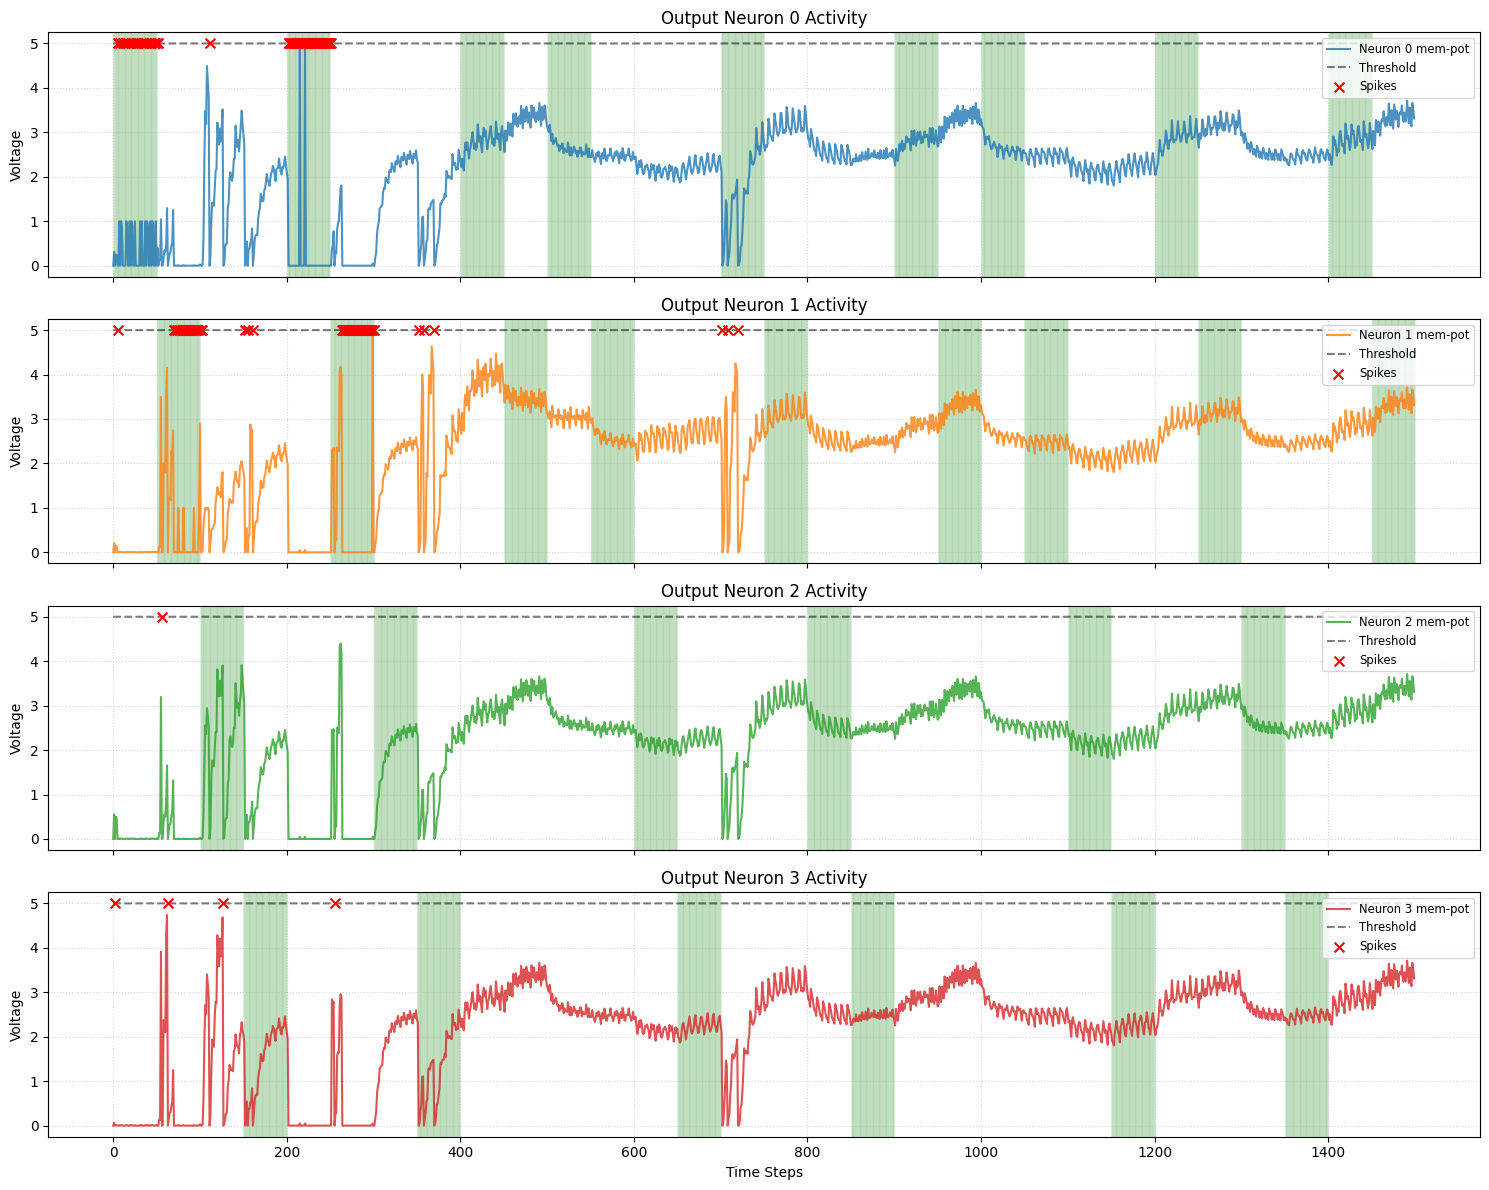


Final Accuracy: 83.7%
Correct: 123/147


In [66]:
# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")

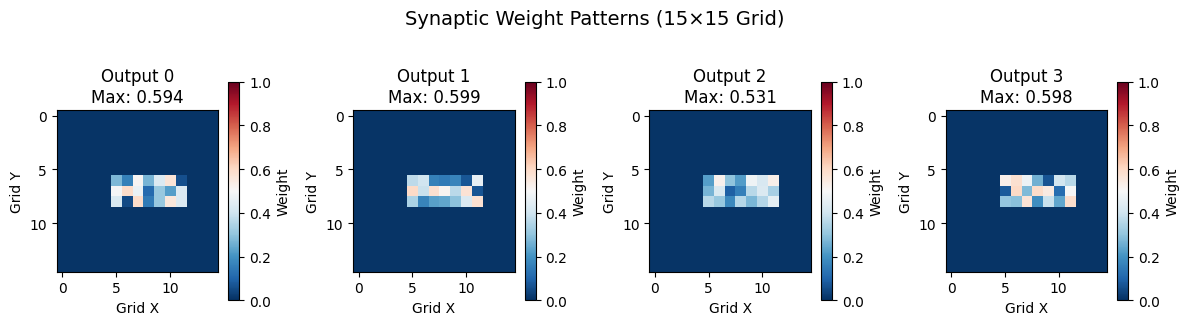

Weight min/max: 0.0100 / 0.5988


In [67]:
import matplotlib.pyplot as plt
import numpy as np

def plot_output_weight_grids(input_to_output_synapses, grid_size=15, figsize=(12, 3)):
    """
    Plot weight heatmap for each output neuron as a 2D grid.
    Assumes inputs represent a flattened occupancy grid.
    
    Parameters:
    -----------
    input_to_output_synapses : numpy.ndarray
        Weight matrix of shape (input_size, output_size)
    grid_size : int
        Size of the square grid (default 15 for 15×15 = 225 inputs)
    """
    n_outputs = input_to_output_synapses.shape[1]
    
    fig, axes = plt.subplots(1, n_outputs, figsize=figsize)
    if n_outputs == 1:
        axes = [axes]
    
    for j, ax in enumerate(axes):
        weights = input_to_output_synapses[:, j]
        
        # Reshape to 2D grid
        weight_grid = weights.reshape(grid_size, grid_size)
        
        im = ax.imshow(weight_grid, cmap='RdBu_r', vmin=0, vmax=1.0)
        ax.set_title(f'Output {j}\nMax: {weights.max():.3f}')
        ax.set_xlabel('Grid X')
        ax.set_ylabel('Grid Y')
        plt.colorbar(im, ax=ax, label='Weight')
        
        # Add grid lines
        ax.grid(False)
    
    plt.suptitle('Synaptic Weight Patterns (15×15 Grid)', fontsize=14, y=1.05)
    plt.tight_layout()
    return fig



# Use the grid visualization:
fig1 = plot_output_weight_grids(input_to_output_synapses, grid_size=15)


plt.show()

print(f"Weight min/max: {input_to_output_synapses.min():.4f} / {input_to_output_synapses.max():.4f}")